# Cat vs Dog CNN Prototype
This notebook demonstrates a simple Convolutional Neural Network (CNN) for classifying images of cats and dogs using a small sample of 10 images.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile

def prepare_data():
    # Using a stable mirror for the Cats vs Dogs dataset
    url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
    dataset_zip = "cats_dogs.zip"

    if os.path.exists(dataset_zip):
        os.remove(dataset_zip)

    print("Downloading dataset (this may take a moment)...")
    !curl -L -o {dataset_zip} {url}

    print("Extracting images...")
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall('dataset_raw')
    print("Extraction complete.")

if not os.path.exists('dataset_raw'):
    prepare_data()

# Define paths for 5 cats and 5 dogs
cat_dir = 'dataset_raw/PetImages/Cat'
dog_dir = 'dataset_raw/PetImages/Dog'

# Get valid jpg files (skipping potential system files like Thumbs.db)
cat_files = [os.path.join(cat_dir, f) for f in os.listdir(cat_dir) if f.endswith('.jpg')][:5]
dog_files = [os.path.join(dog_dir, f) for f in os.listdir(dog_dir) if f.endswith('.jpg')][:5]

image_paths = cat_files + dog_files
labels = [0]*5 + [1]*5
print(f"Successfully found {len(image_paths)} images for the demo.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0   159M      0  0:00:04  0:00:04 --:--:--  162M
Extracting images...
Extraction complete.
Successfully found 10 images for the demo.


## Define the CNN Architecture
We use a simple stack of Convolutional and Pooling layers.

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,327,937 (20.32 MB)

 Trainable params: 5,327,937 (20.32 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model
Since the model was just initialized, its weights are random, which is why the predictions are incorrect. Let's train it for a few epochs on our 10 sample images to demonstrate the learning process.

In [ ]:
# Prepare the 10 images for training
x_train = []
for img_path in image_paths:
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    x_train.append(tf.keras.preprocessing.image.img_to_array(img) / 255.0)

x_train = np.array(x_train)
y_train = np.array(labels)

# Train for 10 epochs to show learning
print("Training the model on the 10 images...")
model.fit(x_train, y_train, epochs=10, verbose=1)

Training the model on the 10 images...
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6945
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.5000 - loss: 1.6704
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step - accuracy: 0.5000 - loss: 0.7341
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - accuracy: 0.5000 - loss: 0.6877
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.8000 - loss: 0.5511
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.5000 - loss: 0.5485
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8000 - loss: 0.4391
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 1.0000 - loss: 0.3730
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - accuracy: 1.0000 - loss: 0.3011
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step - accuracy: 1.0000 - loss: 0.2253


After training, you can re-run the prediction cell below to see the updated results!

## Preprocess and Predict
We resize the 10 images and show the model's prediction.

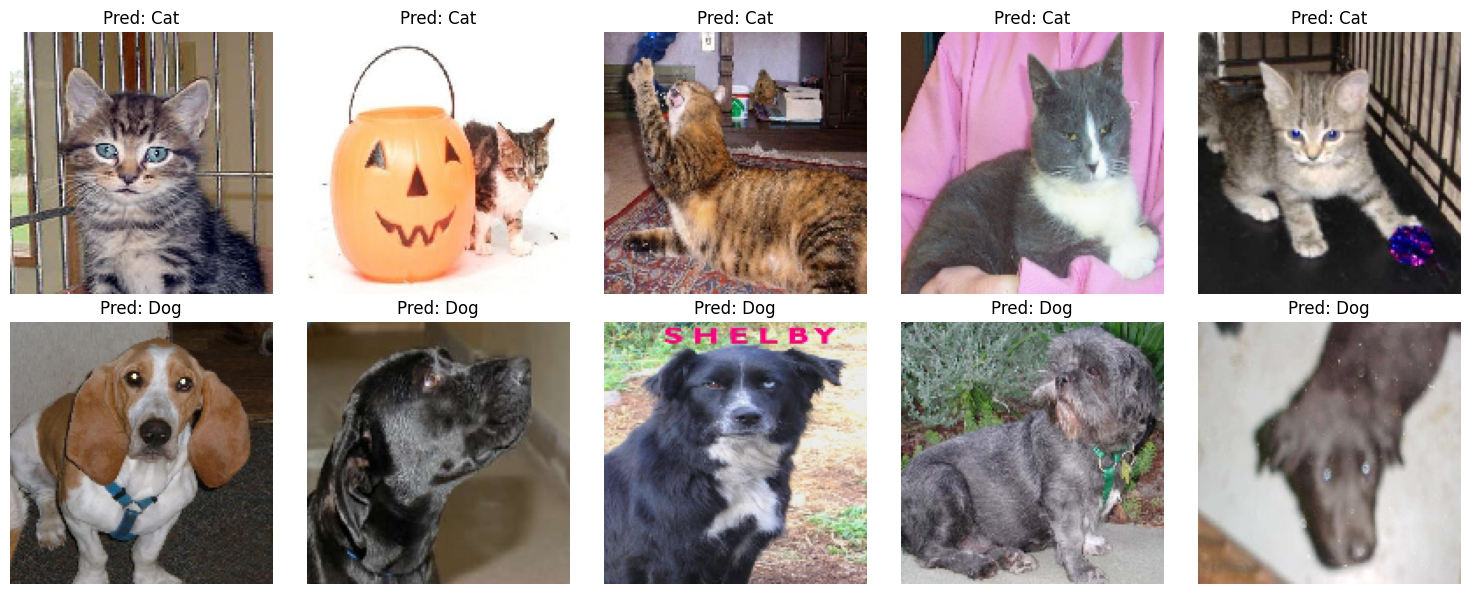

In [ ]:
plt.figure(figsize=(15, 6))
for i, img_path in enumerate(image_paths):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    x = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    prediction = model.predict(x, verbose=0)[0][0]
    pred_label = "Dog" if prediction > 0.5 else "Cat"

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()